# Feature Engineering & Selection

Builds on the cleaned data from notebook 01. Engineering and selection logic lives in `src/feature_engineering.py` and `src/feature_selection.py` — this notebook explores and validates those functions, it doesn't redefine them.

In [1]:
import sys
sys.path.append("..")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_cleaning import load_clean_data
from src.feature_engineering import add_engineered_features, encode_categorical_features
from src.feature_selection import compute_mutual_information, find_highly_correlated_pairs

sns.set_style("whitegrid")
FIGURES_DIR = "../reports/figures"

df_clean = load_clean_data("../data/raw/Telco-Customer-Churn.csv")
df_features = add_engineered_features(df_clean)
df_features[["tenure", "tenure_group", "avg_monthly_spend", "num_additional_services", "has_multiple_services", "is_new_customer"]].head()

,tenure,tenure_group,avg_monthly_spend,num_additional_services,has_multiple_services,is_new_customer
0,1,0-12,29.850000,1,0,1
1,34,25-48,55.573529,2,0,0
2,2,0-12,54.075000,2,0,1
3,45,25-48,40.905556,3,1,0
4,2,0-12,75.825000,0,0,1


## New Features vs. Churn

Validating that the engineered features actually carry signal before feeding them into a model — no point adding complexity for features that don't separate churners from non-churners.

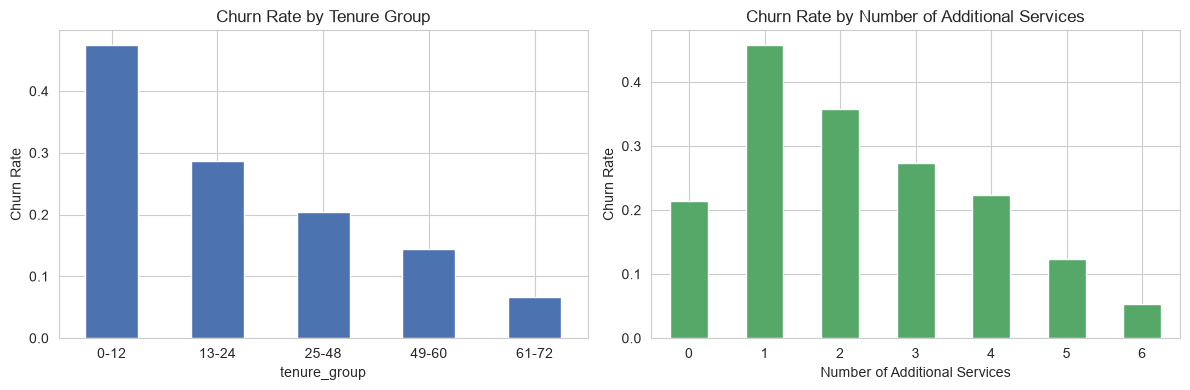

tenure_group
0-12     0.474382
13-24    0.287109
25-48    0.203890
49-60    0.144231
61-72    0.066098
Name: Churn, dtype: float64

num_additional_services
0    0.214060
1    0.457557
2    0.358180
3    0.273703
4    0.223005
5    0.124343
6    0.052817
Name: Churn, dtype: float64


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

tenure_group_churn = df_features.groupby("tenure_group", observed=True)["Churn"].mean()
tenure_group_churn.plot(kind="bar", ax=axes[0], color="#4C72B0")
axes[0].set_title("Churn Rate by Tenure Group")
axes[0].set_ylabel("Churn Rate")
axes[0].tick_params(axis="x", rotation=0)

services_churn = df_features.groupby("num_additional_services")["Churn"].mean()
services_churn.plot(kind="bar", ax=axes[1], color="#55A868")
axes[1].set_title("Churn Rate by Number of Additional Services")
axes[1].set_ylabel("Churn Rate")
axes[1].set_xlabel("Number of Additional Services")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/engineered_features_churn.png", dpi=150)
plt.show()

print(tenure_group_churn)
print()
print(services_churn)

## Encode Categorical Features

In [3]:
df_encoded = encode_categorical_features(df_features)
print(f"Shape after encoding: {df_encoded.shape}")

X = df_encoded.drop(columns=["Churn"])
y = df_encoded["Churn"]
X.columns.tolist()

Shape after encoding: (7043, 39)


['SeniorCitizen',
 'tenure',
 'MonthlyCharges',
 'TotalCharges',
 'avg_monthly_spend',
 'num_additional_services',
 'has_multiple_services',
 'is_new_customer',
 'gender_Male',
 'Partner_Yes',
 'Dependents_Yes',
 'PhoneService_Yes',
 'MultipleLines_No phone service',
 'MultipleLines_Yes',
 'InternetService_Fiber optic',
 'InternetService_No',
 'OnlineSecurity_No internet service',
 'OnlineSecurity_Yes',
 'OnlineBackup_No internet service',
 'OnlineBackup_Yes',
 'DeviceProtection_No internet service',
 'DeviceProtection_Yes',
 'TechSupport_No internet service',
 'TechSupport_Yes',
 'StreamingTV_No internet service',
 'StreamingTV_Yes',
 'StreamingMovies_No internet service',
 'StreamingMovies_Yes',
 'Contract_One year',
 'Contract_Two year',
 'PaperlessBilling_Yes',
 'PaymentMethod_Credit card (automatic)',
 'PaymentMethod_Electronic check',
 'PaymentMethod_Mailed check',
 'tenure_group_13-24',
 'tenure_group_25-48',
 'tenure_group_49-60',
 'tenure_group_61-72']

## Mutual Information — Feature Ranking

Mutual information captures both linear and non-linear relationships with the target, which makes it a better first-pass filter than correlation alone.

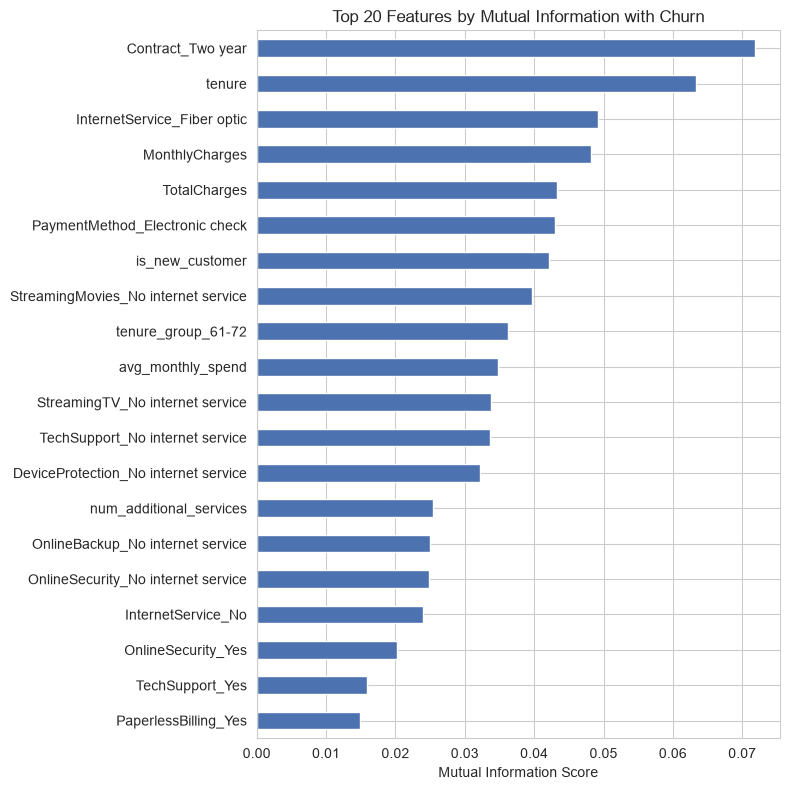

Contract_Two year                       0.071849
tenure                                  0.063314
InternetService_Fiber optic             0.049190
MonthlyCharges                          0.048263
TotalCharges                            0.043235
PaymentMethod_Electronic check          0.042953
is_new_customer                         0.042096
StreamingMovies_No internet service     0.039741
tenure_group_61-72                      0.036182
avg_monthly_spend                       0.034748
StreamingTV_No internet service         0.033812
TechSupport_No internet service         0.033614
DeviceProtection_No internet service    0.032227
num_additional_services                 0.025435
OnlineBackup_No internet service        0.025033
OnlineSecurity_No internet service      0.024882
InternetService_No                      0.023966
OnlineSecurity_Yes                      0.020215
TechSupport_Yes                         0.015914
PaperlessBilling_Yes                    0.014865
dtype: float64

In [4]:
mi_scores = compute_mutual_information(X, y)

fig, ax = plt.subplots(figsize=(8, 8))
mi_scores.head(20).sort_values().plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_title("Top 20 Features by Mutual Information with Churn")
ax.set_xlabel("Mutual Information Score")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/feature_importance_mutual_info.png", dpi=150)
plt.show()

mi_scores.head(20)

## Redundancy Check — Highly Correlated Feature Pairs

Engineered features are often derived from existing ones (e.g. `avg_monthly_spend` from `TotalCharges` and `tenure`), so we should check for near-duplicate information before finalizing the feature set.

In [5]:
correlated_pairs = find_highly_correlated_pairs(X, threshold=0.85)
for col_a, col_b, corr_value in correlated_pairs:
    print(f"{col_a}  <->  {col_b}: {corr_value}")

PhoneService_Yes  <->  MultipleLines_No phone service: 1.0
InternetService_No  <->  OnlineSecurity_No internet service: 1.0
InternetService_No  <->  OnlineBackup_No internet service: 1.0
InternetService_No  <->  DeviceProtection_No internet service: 1.0
InternetService_No  <->  TechSupport_No internet service: 1.0
InternetService_No  <->  StreamingTV_No internet service: 1.0
InternetService_No  <->  StreamingMovies_No internet service: 1.0
OnlineSecurity_No internet service  <->  OnlineBackup_No internet service: 1.0
OnlineSecurity_No internet service  <->  DeviceProtection_No internet service: 1.0
OnlineSecurity_No internet service  <->  TechSupport_No internet service: 1.0
OnlineSecurity_No internet service  <->  StreamingTV_No internet service: 1.0
OnlineSecurity_No internet service  <->  StreamingMovies_No internet service: 1.0
OnlineBackup_No internet service  <->  DeviceProtection_No internet service: 1.0
OnlineBackup_No internet service  <->  TechSupport_No internet service: 1.0

## Finalize Feature Set

_Drop list filled in after reviewing the redundancy check above._

In [6]:
# Redundant features identified from the correlation check above:
# - avg_monthly_spend: 99.6% correlated with MonthlyCharges (the engineered
#   feature didn't add meaningfully new information despite having decent
#   individual mutual information with the target)
# - MultipleLines_No phone service: perfectly redundant with PhoneService_Yes
# - The six "*_No internet service" dummies (OnlineSecurity, OnlineBackup,
#   DeviceProtection, TechSupport, StreamingTV, StreamingMovies): perfectly
#   redundant with InternetService_No, since a customer with no internet
#   service mechanically has "No internet service" for every dependent service
# - has_multiple_services: a coarser binarization of num_additional_services
#   (0.87 correlated) that doesn't add information beyond the count itself
columns_to_drop = [
    "avg_monthly_spend",
    "MultipleLines_No phone service",
    "OnlineSecurity_No internet service",
    "OnlineBackup_No internet service",
    "DeviceProtection_No internet service",
    "TechSupport_No internet service",
    "StreamingTV_No internet service",
    "StreamingMovies_No internet service",
    "has_multiple_services",
]

X_selected = X.drop(columns=columns_to_drop)
final_dataset = X_selected.copy()
final_dataset["Churn"] = y

final_dataset.to_csv("../data/processed/telco_features.csv", index=False)
print(f"Saved final feature set: {final_dataset.shape}")
print(f"Dropped as redundant: {columns_to_drop}")

Saved final feature set: (7043, 30)
Dropped as redundant: ['avg_monthly_spend', 'MultipleLines_No phone service', 'OnlineSecurity_No internet service', 'OnlineBackup_No internet service', 'DeviceProtection_No internet service', 'TechSupport_No internet service', 'StreamingTV_No internet service', 'StreamingMovies_No internet service', 'has_multiple_services']


## Key Findings

- **`Contract_Two year`, `tenure`, and `InternetService_Fiber optic` top the mutual information ranking** — consistent with the univariate patterns seen in EDA (notebook 01), which is a good sanity check that the two analyses agree.
- **The engineered features earned their place**: `is_new_customer` ranks 7th by mutual information, and `tenure_group_61-72` ranks 9th — both ahead of several raw one-hot encoded columns. Bucketing tenure and flagging new customers captured real, non-redundant signal.
- **One engineered feature failed validation and was dropped**: `avg_monthly_spend` looked promising in isolation (reasonable individual mutual information), but turned out to be 99.6% correlated with the existing `MonthlyCharges` column — it wasn't adding new information, just restating an existing feature in a different form. Keeping it would have added noise/multicollinearity without benefit.
- **One-hot encoding a 3-category column (Yes / No / No internet service) creates structural redundancy**: because "No internet service" for `OnlineSecurity`, `OnlineBackup`, etc. is mechanically determined by `InternetService == "No"`, six dummy columns were perfectly (1.0) correlated with `InternetService_No` and each other. Dropped in favor of the single `InternetService_No` indicator.
- **Final feature set: 29 features + target**, down from 38 after encoding — removed for redundancy, not because they lacked individual signal. This distinction matters: a feature can be informative on its own and still be dropped if another feature already captures that information.

Saved to `data/processed/telco_features.csv` for use in the modeling stage.